In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, accuracy_score)
import xgboost as xgb

print("✅ All libraries imported!")

✅ All libraries imported!


In [2]:
# Using Breast Cancer dataset — binary classification (malignant vs benign)
# 569 samples, 30 features — perfect for disease prediction
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("Dataset Shape:", df.shape)
print("\nClass Distribution:")
print(df['target'].value_counts().rename({0: 'Malignant', 1: 'Benign'}))
print("\nSample Features:")
print(df.head(3))
print("\nMissing Values:", df.isnull().sum().sum())

Dataset Shape: (569, 31)

Class Distribution:
target
Benign       357
Malignant    212
Name: count, dtype: int64

Sample Features:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38           122.8     1001.0          0.11840   
1        20.57         17.77           132.9     1326.0          0.08474   
2        19.69         21.25           130.0     1203.0          0.10960   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0                 0.07871  ...          17.33            184.6      2019.0   
1                 0.05667  ...          23.41            158.8      1956.0   
2                 0.05999  ..

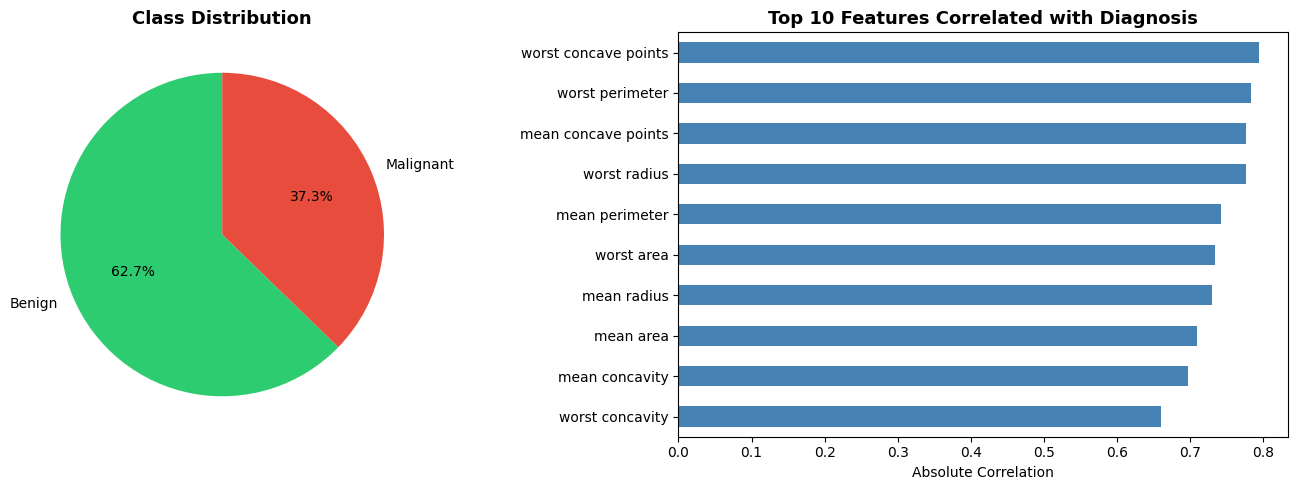

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution
axes[0].pie(df['target'].value_counts(),
            labels=['Benign', 'Malignant'],
            autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'],
            startangle=90)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')

# Feature correlation with target — top 10
correlations = df.corr()['target'].drop('target').abs().sort_values(ascending=False)
correlations.head(10).plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 10 Features Correlated with Diagnosis', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Absolute Correlation')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [4]:
X = df.drop('target', axis=1)
y = df['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features — important for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Features         : {X_train.shape[1]}")

Training samples : 455
Test samples     : 114
Features         : 30


In [5]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest"      : RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost"            : xgb.XGBClassifier(n_estimators=100, random_state=42,
                                              eval_metric='logloss', verbosity=0)
}

results = {}

for name, model in models.items():
    # Logistic Regression needs scaled data
    X_tr = X_train_scaled if name == "Logistic Regression" else X_train
    X_te = X_test_scaled  if name == "Logistic Regression" else X_test

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    acc     = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results[name] = {
        'model'  : model,
        'y_pred' : y_pred,
        'y_prob' : y_prob,
        'acc'    : acc,
        'roc_auc': roc_auc
    }
    print(f"✅ {name:25s} | Accuracy: {acc:.4f} | ROC-AUC: {roc_auc:.4f}")

✅ Logistic Regression       | Accuracy: 0.9825 | ROC-AUC: 0.9954
✅ Random Forest             | Accuracy: 0.9561 | ROC-AUC: 0.9937
✅ XGBoost                   | Accuracy: 0.9561 | ROC-AUC: 0.9927


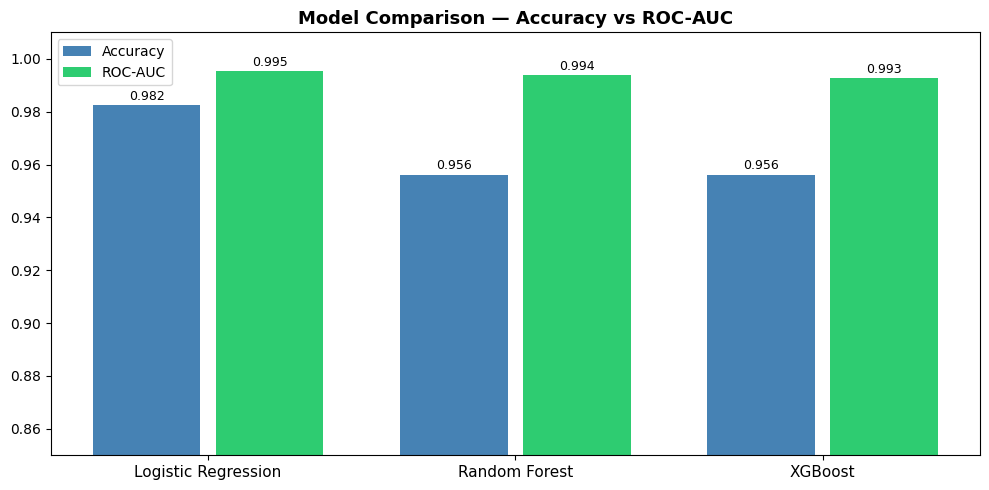

In [6]:
# Bar chart comparison
names    = list(results.keys())
accs     = [results[n]['acc']     for n in names]
roc_aucs = [results[n]['roc_auc'] for n in names]

x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - 0.2, accs,     0.35, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + 0.2, roc_aucs, 0.35, label='ROC-AUC',  color='#2ecc71')

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=11)
ax.set_ylim(0.85, 1.01)
ax.set_title('Model Comparison — Accuracy vs ROC-AUC', fontsize=13, fontweight='bold')
ax.legend()

for bar in bars1: ax.text(bar.get_x()+bar.get_width()/2,
                           bar.get_height()+0.002,
                           f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2: ax.text(bar.get_x()+bar.get_width()/2,
                           bar.get_height()+0.002,
                           f'{bar.get_height():.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

🏆 Best Model: Logistic Regression

              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



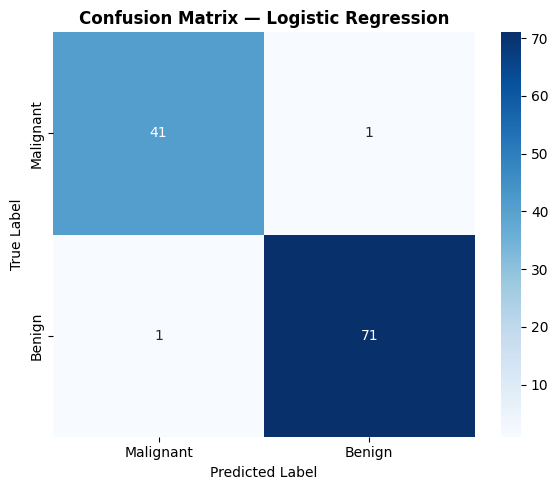

In [7]:
# Pick best model by ROC-AUC
best_name  = max(results, key=lambda n: results[n]['roc_auc'])
best       = results[best_name]
print(f"🏆 Best Model: {best_name}\n")

# Classification Report
print(classification_report(y_test, best['y_pred'],
      target_names=['Malignant', 'Benign']))

# Confusion Matrix
cm = confusion_matrix(y_test, best['y_pred'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant','Benign'],
            yticklabels=['Malignant','Benign'])
plt.title(f'Confusion Matrix — {best_name}', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

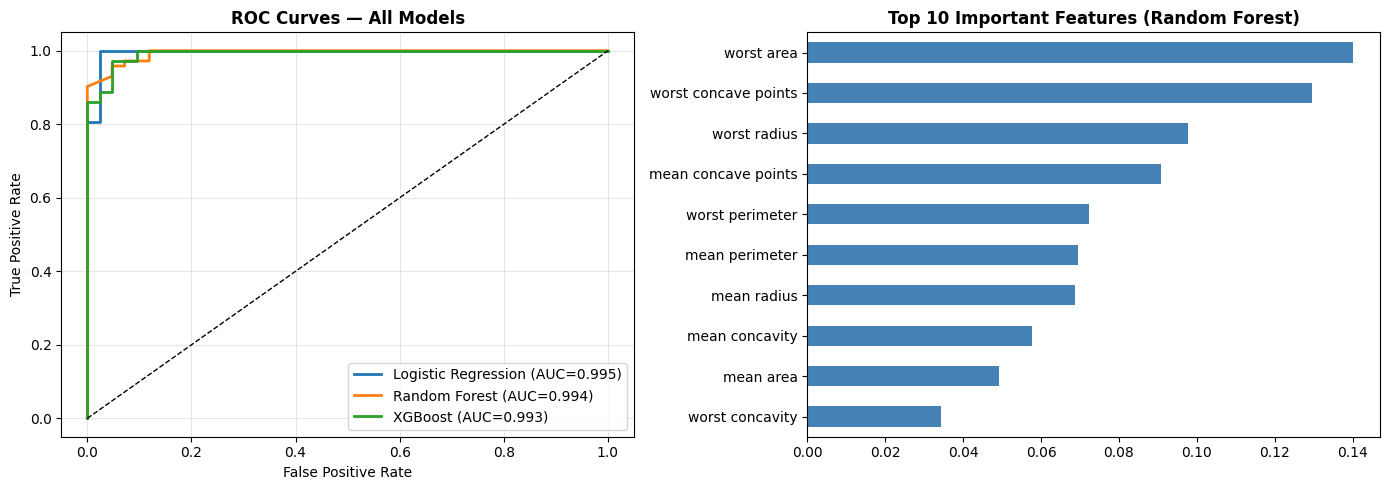

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curves — all 3 models
for name in results:
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
    ax1.plot(fpr, tpr, linewidth=2,
             label=f"{name} (AUC={results[name]['roc_auc']:.3f})")
ax1.plot([0,1],[0,1],'k--', linewidth=1)
ax1.set_title('ROC Curves — All Models', fontweight='bold')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Feature Importance from Random Forest
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_,
                         index=data.feature_names).sort_values(ascending=False)
importances.head(10).plot(kind='barh', ax=ax2, color='steelblue')
ax2.set_title('Top 10 Important Features (Random Forest)', fontweight='bold')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

In [9]:
import joblib

# Save the best model
best_model = results[best_name]['model']
joblib.dump(best_model, 'disease_prediction_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print(f"✅ Model saved: disease_prediction_model.pkl")

# Download
from google.colab import files
files.download('disease_prediction_model.pkl')

✅ Model saved: disease_prediction_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>